In [14]:
import os
import warnings
warnings.filterwarnings('ignore')

# 1. Prevent tokenizer deadlocks
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 2. Install the EXACT branch used during training 
# (This fixes both the Siglip dataclass error and the FSDP error)
!pip uninstall -y transformers accelerate bitsandbytes
!pip install git+https://github.com/huggingface/transformers@v4.49.0-Gemma-3
!pip install -q -U accelerate bitsandbytes peft datasets rouge-score

print("✅ Environment ready with native Gemma 3 support.")

Found existing installation: transformers 4.50.0.dev0
Uninstalling transformers-4.50.0.dev0:
  Successfully uninstalled transformers-4.50.0.dev0
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2
  Cloning https://github.com/huggingface/transformers (to revision v4.49.0-Gemma-3) to /tmp/pip-req-build-5n0yec35
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers /tmp/pip-req-build-5n0yec35
  Running command git checkout -q 1c0f782fe5f983727ff245c4c1b3906f9b99eec2
  Resolved https://github.com/huggingface/transformers to commit 1c0f782fe5f983727ff245c4c1b3906f9b99eec2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=

In [15]:
import torch
print(torch.version.cuda)
device = "cuda" if torch.cuda.is_available() else "cpu"

12.8


In [16]:
from kaggle_secrets import UserSecretsClient
import huggingface_hub

try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    huggingface_hub.login(token=hf_token)
    print("✅ Authenticated with Hugging Face.")
except Exception as e:
    print(f"⚠️ HF_TOKEN not found: {e}. Using default login.")
    huggingface_hub.login()

✅ Authenticated with Hugging Face.


In [17]:
import torch
import gc
import pandas as pd
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import load_dataset
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns
import math

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Load MUSE Data (Required for full 6-way evaluation)
print("Loading MUSE-Books dataset splits...")
try:
    raw_dataset = load_dataset("muse-bench/MUSE-Books", "raw")
    qa_dataset = load_dataset("muse-bench/MUSE-Books", "knowmem")
    
    # Text datasets for VerbMem and PPL
    forget_ds = raw_dataset['forget']
    retain_ds = raw_dataset['retain1'] if 'retain1' in raw_dataset else raw_dataset['retain']
    
    # QA datasets for KnowMem
    qa_forget_key = next((k for k in ['forget_qa', 'forget'] if k in qa_dataset), None)
    qa_retain_key = next((k for k in ['retain_qa', 'retain', 'retain1'] if k in qa_dataset), None)
    
    qa_forget_ds = qa_dataset[qa_forget_key] if qa_forget_key else qa_dataset[list(qa_dataset.keys())[0]]
    qa_retain_ds = qa_dataset[qa_retain_key] if qa_retain_key else qa_dataset[list(qa_dataset.keys())[1]]
    
    print(f"✅ Data loaded: {len(forget_ds)} forget text, {len(retain_ds)} retain text.")
    print(f"✅ QA Data loaded: {len(qa_forget_ds)} forget QA, {len(qa_retain_ds)} retain QA.")
except Exception as e:
    print(f"⚠️ Dataset loading error: {e}")

Loading MUSE-Books dataset splits...
✅ Data loaded: 4 forget text, 12 retain text.
✅ QA Data loaded: 100 forget QA, 100 retain QA.


In [18]:
def load_model_safely(model_path, q_type=None):
    """Load model with proper quantization handling from local path."""
    clean_memory()
    
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    bnb_config = None
    torch_dtype = torch.bfloat16
    
    if q_type == "4bit":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16, 
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True
        )
    elif q_type == "8bit":
        bnb_config = BitsAndBytesConfig(
            load_in_8bit=True,
            bnb_8bit_compute_dtype=torch.float16, 
            bnb_8bit_quant_type="nf8",
            bnb_8bit_use_double_quant=True
        )
    elif q_type == "int8":
        bnb_config = BitsAndBytesConfig(load_in_8bit=True)
    
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        quantization_config=bnb_config,
        torch_dtype=torch_dtype if q_type is None else None,
        device_map="auto",
        trust_remote_code=True
    )
    
    return model, tokenizer








def compute_verbmem_rouge(model, tokenizer, forget_ds, num_samples=50):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    total_rouge_l_f1 = 0.0
    processed = 0
    
    model.eval()
    for item in forget_ds:
        if processed >= num_samples: break
        try:
            text = str(item.get('text', item))
            words = text.split()
            if len(words) < 50: continue
            
            prompt = " ".join(words[:30])
            target_answer = " ".join(words[30:50]).lower()
            
            # --- YOUR MATH ---
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            input_length = inputs["input_ids"].shape[1] # Track exact token length
            
            outputs = model.generate(**inputs, max_new_tokens=30, pad_token_id=tokenizer.eos_token_id)
            
            # Slice the tokens directly before decoding
            new_tokens = outputs[0][input_length:]
            continuation = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()
            
            score = scorer.score(target_answer, continuation)
            total_rouge_l_f1 += score['rougeL'].fmeasure
            processed += 1
        except: continue
        
    return (total_rouge_l_f1 / processed) if processed > 0 else 0.0

def compute_knowmem_rouge(model, tokenizer, qa_ds, num_samples=50):
    if qa_ds is None: return 0.0
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    total_rouge_l_f1 = 0.0
    processed = 0
    
    model.eval()
    for item in qa_ds:
        if processed >= num_samples: break
        try:
            prompt = item.get('question', item.get('prompt', ''))
            target_answer = item.get('answer', item.get('target', '')).lower()
            if not prompt or not target_answer: continue
            
            # --- YOUR MATH ---
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            input_length = inputs["input_ids"].shape[1] # Track exact token length
            
            outputs = model.generate(**inputs, max_new_tokens=30, pad_token_id=tokenizer.eos_token_id)
            
            # Slice the tokens directly before decoding
            new_tokens = outputs[0][input_length:]
            continuation = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()
            
            score = scorer.score(target_answer, continuation)
            total_rouge_l_f1 += score['rougeL'].fmeasure
            processed += 1
        except: continue
        
    return (total_rouge_l_f1 / processed) if processed > 0 else 0.0

def compute_utility_perplexity(model, tokenizer, dataset, num_samples=50):
    if not dataset or len(dataset) == 0: 
        return float('inf')
    
    # Try logic for HuggingFace datasets, fallback to list logic
    try:
        text_col = 'text' if 'text' in dataset.column_names else dataset.column_names[0]
        subset = dataset.select(range(min(num_samples, len(dataset))))
    except AttributeError:
        text_col = 'text'
        subset = dataset[:min(num_samples, len(dataset))]
        
    total_loss = 0.0
    total_length = 0
    
    model.eval()
    with torch.no_grad():
        for item in subset:
            try:
                # Fallback to direct string conversion if dict key fails
                text = item.get(text_col, str(item)) if isinstance(item, dict) else str(item)
                
                # --- YOUR MATH ---
                inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)
                
                if inputs['input_ids'].size(1) < 2:
                    continue
                    
                outputs = model(
                    input_ids=inputs['input_ids'], 
                    attention_mask=inputs['attention_mask'], 
                    labels=inputs["input_ids"]
                )
                
                # Causal LM loss is calculated over N-1 tokens
                valid_seq_len = inputs['input_ids'].size(1) - 1 
                
                total_loss += outputs.loss.item() * valid_seq_len
                total_length += valid_seq_len
            except: continue
            
    if total_length == 0: 
        return float('inf')
        
    avg_loss = total_loss / total_length
    
    if avg_loss > 20: 
        return float('inf')
        
    return math.exp(avg_loss)

# ==============================================================================
# 6. BENCHMARK EXECUTION (UNTOUCHED)
# ==============================================================================
results = []
print("\n" + "="*80)
print("RUNNING FULL MUSE 6-WAY BENCHMARK ON LOCAL MODELS")
print("="*80 + "\n")

for name, path, q_type in MODEL_REGISTRY:
    if not os.path.exists(path):
        print(f"⏭️ Skipping {name}: Directory not found at {path}")
        continue

    print(f"\n{'─'*80}")
    print(f"Loading: {name} | Quantization: {q_type or 'None (FP16)'}")
    print(f"{'─'*80}")
    
    try:
        model, tokenizer = load_model_safely(path, q_type)
        
        print("Computing QA Conceptual Knowledge (KnowMem)...", end=" ")
        forget_qa_rouge = compute_knowmem_rouge(model, tokenizer, qa_forget_ds, num_samples=50)
        retain_qa_rouge = compute_knowmem_rouge(model, tokenizer, qa_retain_ds, num_samples=50)
        print("✅ Done")
        
        print("Computing Raw Text Verbatim Recall (VerbMem)...", end=" ")
        forget_raw_rouge = compute_verbmem_rouge(model, tokenizer, forget_ds, num_samples=50)
        retain_raw_rouge = compute_verbmem_rouge(model, tokenizer, retain_ds, num_samples=50)
        print("✅ Done")
        
        print("Computing Utility Perplexity (PPL)...", end=" ")
        forget_ppl = compute_utility_perplexity(model, tokenizer, forget_ds, num_samples=30)
        retain_ppl = compute_utility_perplexity(model, tokenizer, retain_ds, num_samples=30)
        print("✅ Done")
        
        results.append({
            "Model": name,
            "Forget QA ROUGE": forget_qa_rouge,
            "Retain QA ROUGE": retain_qa_rouge,
            "Forget Raw ROUGE": forget_raw_rouge,
            "Retain Raw ROUGE": retain_raw_rouge,
            "Forget PPL": forget_ppl,
            "Retain PPL": retain_ppl,
            "Quantized": "Yes" if q_type else "No"
        })
        
        print(f"\n✅ Success: {name}")
        del model, tokenizer
        import gc
        gc.collect()
        torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"\n❌ Failed {name}\nError: {str(e)[:200]}")
        continue

print("\n" + "="*80)
print("BENCHMARK COMPLETE")
print("="*80)
if results:
    print(pd.DataFrame(results))

✅ Method 1 (Robust) metrics and loading utilities implemented.


In [19]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for filename in files:
        print(os.path.join(root, filename))

/kaggle/input/models/harshkapoor715/npo/transformers/default/1/model (1).safetensors
/kaggle/input/models/anurag2006/tv-models/transformers/default/2/tv_models/unlearned_task_vector/config.json
/kaggle/input/models/anurag2006/tv-models/transformers/default/2/tv_models/unlearned_task_vector/tokenizer.json
/kaggle/input/models/anurag2006/tv-models/transformers/default/2/tv_models/unlearned_task_vector/tokenizer_config.json
/kaggle/input/models/anurag2006/tv-models/transformers/default/2/tv_models/unlearned_task_vector/chat_template.jinja
/kaggle/input/models/anurag2006/tv-models/transformers/default/2/tv_models/unlearned_task_vector/model.safetensors
/kaggle/input/models/anurag2006/tv-models/transformers/default/2/tv_models/unlearned_task_vector/generation_config.json
/kaggle/input/models/anurag2006/tv-models/transformers/default/2/tv_models/fine_tuned_forget/config.json
/kaggle/input/models/anurag2006/tv-models/transformers/default/2/tv_models/fine_tuned_forget/tokenizer.json
/kaggle/in

In [27]:
import os
import shutil
import torch
from transformers import AutoConfig, AutoTokenizer

# ==============================================================================
# 1. DYNAMIC PATH DISCOVERY
# ==============================================================================
print("🔍 Searching for model files...")

TV_VECTOR_PATH = ""
NPO_INPUT_FILE = ""

for root, dirs, files in os.walk('/kaggle/input'):
    # Search for the TV Vector directory
    if 'unlearned_task_vector' in dirs:
        TV_VECTOR_PATH = os.path.join(root, 'unlearned_task_vector')
    
    # Search for the specific NPO weights file
    if 'model (1).safetensors' in files:
        NPO_INPUT_FILE = os.path.join(root, 'model (1).safetensors')

# ==============================================================================
# 2. PREPARE WRITABLE NPO DIRECTORY (Gemma 3 Fix)
# ==============================================================================
NPO_DIR = "/kaggle/working/npo_model_fixed"
os.makedirs(NPO_DIR, exist_ok=True)

# Use Gemma 3 base for Config and Tokenizer to avoid 'k_norm' errors
# Ensure you have accepted the Gemma 3 license on Hugging Face!
GEMMA_3_ID = "google/gemma-3-1b-pt" 

if NPO_INPUT_FILE:
    print(f"✅ Found NPO weights: {NPO_INPUT_FILE}")
    shutil.copy(NPO_INPUT_FILE, os.path.join(NPO_DIR, "model.safetensors"))
    
    print(f"📥 Fetching Gemma 3 metadata from {GEMMA_3_ID}...")
    try:
        # Load and save config
        config = AutoConfig.from_pretrained(GEMMA_3_ID, trust_remote_code=True)
        config.save_pretrained(NPO_DIR)
        
        # Load and save tokenizer (Essential for the benchmark loader)
        tokenizer = AutoTokenizer.from_pretrained(GEMMA_3_ID, trust_remote_code=True)
        tokenizer.save_pretrained(NPO_DIR)
        print("✅ NPO Directory is ready for Gemma 3.")
    except Exception as e:
        print(f"❌ Error fetching Gemma 3 files: {e}")
        print("💡 Hint: Check your Hugging Face Token/Permissions.")
else:
    print("❌ CRITICAL: Could not find 'model (1).safetensors' in /kaggle/input.")

# ==============================================================================
# 3. VALIDATION & REGISTRY
# ==============================================================================
print("\n--- Final Status ---")
if TV_VECTOR_PATH:
    print(f"✅ TV Vector Found: {TV_VECTOR_PATH}")
else:
    print("❌ TV Vector still missing! Check if the dataset is attached.")

# Use the discovered paths in your registry
MODEL_REGISTRY = [
    ("NPO Unlearned (FP16)", NPO_DIR, None),
    ("NPO Unlearned (NF8)",  NPO_DIR, "8bit"),
    ("NPO Unlearned (NF4)",  NPO_DIR, "4bit"),

    ("TV Unlearned (FP16)", TV_VECTOR_PATH, None),
    ("TV Unlearned (NF8)",  TV_VECTOR_PATH, "8bit"),
    ("TV Unlearned (NF4)",  TV_VECTOR_PATH, "4bit"),
]


results = []
print("\n" + "="*80)
print("RUNNING FULL MUSE 6-WAY BENCHMARK ON LOCAL MODELS")
print("="*80 + "\n")

for name, path, q_type in MODEL_REGISTRY:
    if not os.path.exists(path):
        print(f"⏭️ Skipping {name}: Directory not found at {path}")
        continue

    print(f"\n{'─'*80}")
    print(f"Loading: {name} | Quantization: {q_type or 'None (FP16)'}")
    print(f"{'─'*80}")
    
    try:
        model, tokenizer = load_model_safely(path, q_type)
        
        print("Computing QA Conceptual Knowledge (KnowMem)...", end=" ")
        forget_qa_rouge = compute_knowmem_rouge(model, tokenizer, qa_forget_ds, num_samples=50)
        retain_qa_rouge = compute_knowmem_rouge(model, tokenizer, qa_retain_ds, num_samples=50)
        print("✅ Done")
        
        print("Computing Raw Text Verbatim Recall (VerbMem)...", end=" ")
        forget_raw_rouge = compute_verbmem_rouge(model, tokenizer, forget_ds, num_samples=50)
        retain_raw_rouge = compute_verbmem_rouge(model, tokenizer, retain_ds, num_samples=50)
        print("✅ Done")
        
        print("Computing Utility Perplexity (PPL)...", end=" ")
        forget_ppl = compute_utility_perplexity(model, tokenizer, forget_ds, num_samples=30)
        retain_ppl = compute_utility_perplexity(model, tokenizer, retain_ds, num_samples=30)
        print("✅ Done")
        
        results.append({
            "Model": name,
            "Forget QA ROUGE": forget_qa_rouge,
            "Retain QA ROUGE": retain_qa_rouge,
            "Forget Raw ROUGE": forget_raw_rouge,
            "Retain Raw ROUGE": retain_raw_rouge,
            "Forget PPL": forget_ppl,
            "Retain PPL": retain_ppl,
            "Quantized": "Yes" if q_type else "No"
        })
        
        print(f"\n✅ Success: {name}")
        del model, tokenizer
        clean_memory()
        
    except Exception as e:
        print(f"\n❌ Failed {name}\nError: {str(e)[:200]}")
        continue

print("\n" + "="*80)
print("BENCHMARK COMPLETE")
print("="*80)

🔍 Searching for model files...
✅ Found NPO weights: /kaggle/input/models/harshkapoor715/npo/transformers/default/1/model (1).safetensors
📥 Fetching Gemma 3 metadata from google/gemma-3-1b-pt...
✅ NPO Directory is ready for Gemma 3.

--- Final Status ---
✅ TV Vector Found: /kaggle/input/models/anurag2006/tv-models/transformers/default/2/tv_models/unlearned_task_vector

RUNNING FULL MUSE 6-WAY BENCHMARK ON LOCAL MODELS


────────────────────────────────────────────────────────────────────────────────
Loading: NPO Unlearned (FP16) | Quantization: None (FP16)
────────────────────────────────────────────────────────────────────────────────
Computing QA Conceptual Knowledge (KnowMem)... ✅ Done
Computing Raw Text Verbatim Recall (VerbMem)... ✅ Done
Computing Utility Perplexity (PPL)... ✅ Done

✅ Success: NPO Unlearned (FP16)

────────────────────────────────────────────────────────────────────────────────
Loading: NPO Unlearned (NF8) | Quantization: 8bit
──────────────────────────────────────


FINAL BENCHMARK RESULTS (MUSE 6-Way Evaluation)
               Model  Forget QA ROUGE  Retain QA ROUGE  Forget Raw ROUGE  Retain Raw ROUGE   Forget PPL  Retain PPL Quantized
NPO Unlearned (FP16)         0.057934         0.122138          0.122571          0.106316    38.932397   13.951795        No
 NPO Unlearned (NF8)         0.053228         0.121991          0.131751          0.102714    38.139855   14.315278       Yes
 NPO Unlearned (NF4)         0.053483         0.086611          0.122363          0.124477    41.930622   17.226158       Yes
 TV Unlearned (FP16)         0.060346         0.053225          0.068765          0.057259  3110.172224  301.367315        No
  TV Unlearned (NF8)         0.059344         0.051134          0.082583          0.065747  3108.100728  318.543643       Yes
  TV Unlearned (NF4)         0.043476         0.030219          0.032258          0.041652 35279.418615 1034.218926       Yes


DELTA ANALYSIS (Unlearning Efficacy & Quantization Snap-Back)
⚠️ No

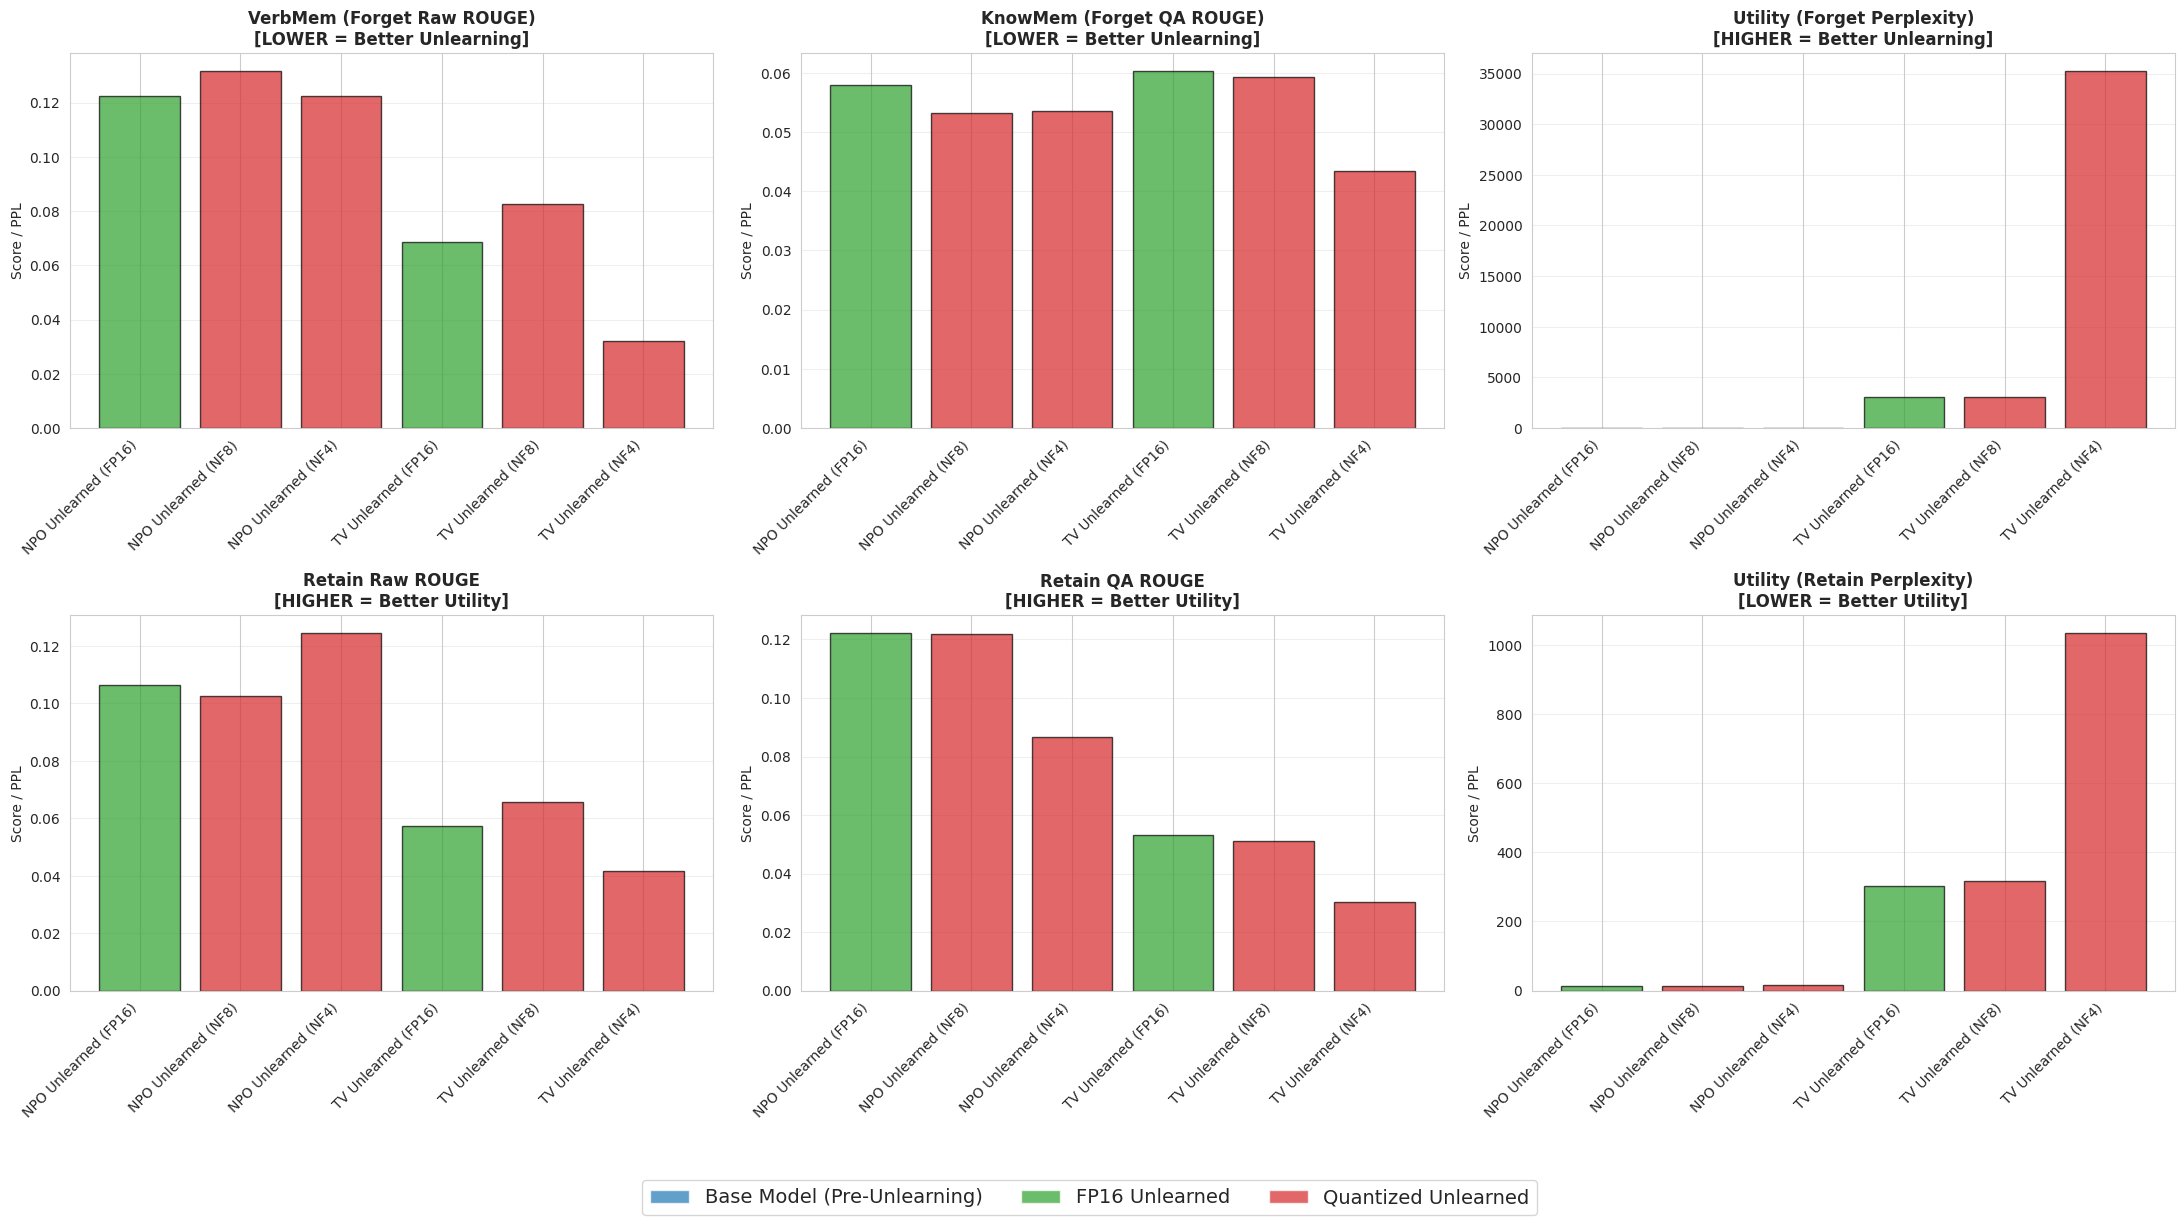

✅ Full Benchmark saved to 'muse_6way_benchmark_results.csv'


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import pandas as pd
import re

if results:
    df = pd.DataFrame(results)
    
    print("\n" + "="*100)
    print("FINAL BENCHMARK RESULTS (MUSE 6-Way Evaluation)")
    print("="*100)
    # 1. Print the entire dataframe cleanly
    print(df.to_string(index=False))
    
    # --- DYNAMIC RECOVERY DELTA ANALYSIS ---
    print("\n\n" + "="*100)
    print("DELTA ANALYSIS (Unlearning Efficacy & Quantization Snap-Back)")
    print("="*100)
    
    # Attempt to locate a Base Model in the results
    base_rows = df[df['Model'].str.contains('Base', case=False, na=False)]
    if not base_rows.empty:
        base_raw_rouge = base_rows['Forget Raw ROUGE'].values[0]
        print(f"Reference Base Model Forget Raw ROUGE: {base_raw_rouge:.5f}\n")
    else:
        base_raw_rouge = None
        print("⚠️ No 'Base' model found in results. Base deltas will be skipped.\n")

    # Group models dynamically into families (e.g., grouping "TV Unlearned FP16" with its "4-bit" and "8-bit" versions)
    model_names = df['Model'].tolist()
    families = {}
    
    for name in model_names:
        if "Base" in name: continue
        # Strip out the precision tags to find the core model name
        core_name = re.sub(r'\s*\((FP16|4-bit|8-bit|INT4|NF4|NF8|INT8)\)', '', name).strip()
        
        if core_name not in families:
            families[core_name] = {'FP16': None, 'Quantized': []}
            
        if "FP16" in name:
            families[core_name]['FP16'] = name
        else:
            families[core_name]['Quantized'].append(name)
            
    # Calculate all Deltas dynamically
    for core_name, variants in families.items():
        fp16_model = variants['FP16']
        print(f"{'─'*80}\nEvaluating Family: {core_name}\n{'─'*80}")
        
        if not fp16_model:
            print("⚠️ No FP16 baseline found for this model to calculate snap-back.\n")
            continue
            
        fp16_score = df[df['Model'] == fp16_model]['Forget Raw ROUGE'].values[0]
        
        # 1. Base vs Unlearned FP16 (Overall Unlearning)
        if base_raw_rouge is not None:
            unlearn_delta = fp16_score - base_raw_rouge
            print(f"📉 Unlearning Drop (Base -> FP16): {unlearn_delta:.5f} (Lower is better)")
            
        # 2. FP16 vs Quantized (Snap-Back) & Base vs Quantized
        for q_model in variants['Quantized']:
            q_score = df[df['Model'] == q_model]['Forget Raw ROUGE'].values[0]
            
            # Snap-back calculation
            delta_rec = q_score - fp16_score
            print(f"\n🔍 {q_model}:")
            print(f"   Recovery Delta (vs FP16): Δ_Rec = {delta_rec:.5f}")
            
            if delta_rec > 0.01:
                print(f"   ⚠️ WARNING: Snap-Back Detected! ({delta_rec*100:.2f}% verbatim increase)")
            else:
                print(f"   ✅ ROBUST: No significant snap-back from quantization.")
                
            # Base vs Quantized calculation
            if base_raw_rouge is not None:
                base_to_q_delta = q_score - base_raw_rouge
                print(f"   Total Net Delta (Base -> Quantized): {base_to_q_delta:.5f}")
        print("\n")

    # --- DYNAMIC VISUALIZATION (2x3 Grid for all 6 Metrics) ---
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    sns.set_style("whitegrid")
    axes = axes.flatten()
    
    # Map out the 6 metrics to plot
    metrics_to_plot = [
        ('Forget Raw ROUGE', 'VerbMem (Forget Raw ROUGE)\n[LOWER = Better Unlearning]'),
        ('Forget QA ROUGE', 'KnowMem (Forget QA ROUGE)\n[LOWER = Better Unlearning]'),
        ('Forget PPL', 'Utility (Forget Perplexity)\n[HIGHER = Better Unlearning]'),
        ('Retain Raw ROUGE', 'Retain Raw ROUGE\n[HIGHER = Better Utility]'),
        ('Retain QA ROUGE', 'Retain QA ROUGE\n[HIGHER = Better Utility]'),
        ('Retain PPL', 'Utility (Retain Perplexity)\n[LOWER = Better Utility]')
    ]
    
    # Color-code logic: Base=Blue, FP16=Green, Quantized=Red
    colors = ['#1f77b4' if 'Base' in m else ('#d62728' if q == 'Yes' else '#2ca02c') 
              for m, q in zip(df['Model'], df['Quantized'])]
    
    # Generate all plots
    for idx, (col_name, title) in enumerate(metrics_to_plot):
        ax = axes[idx]
        ax.bar(range(len(df)), df[col_name], color=colors, alpha=0.7, edgecolor='black')
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xticks(range(len(df)))
        ax.set_xticklabels(df['Model'], rotation=45, ha='right', fontsize=10)
        ax.set_ylabel('Score / PPL', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        
    # Build dynamic legend
    legend_elements = [
        Patch(facecolor='#1f77b4', alpha=0.7, label='Base Model (Pre-Unlearning)'),
        Patch(facecolor='#2ca02c', alpha=0.7, label='FP16 Unlearned'),
        Patch(facecolor='#d62728', alpha=0.7, label='Quantized Unlearned')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, fontsize=14)
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()
    
    df.to_csv("muse_6way_benchmark_results.csv", index=False)
    print("✅ Full Benchmark saved to 'muse_6way_benchmark_results.csv'")
else:
    print("❌ No results to display.")